# Import Libraries
***

In [3]:
import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model

from tensorflow.keras.applications.resnet50 import preprocess_input

# Reading The Data
***

In [4]:
DATASET_PATH = "/kaggle/input/datasets/iashiqul/brain-stroke-prediction-ct-scan-image-dataset/Brain_Stroke_CT-SCAN_image"

train_path = os.path.join(DATASET_PATH, "Train")
val_path = os.path.join(DATASET_PATH, "Validation")
test_path = os.path.join(DATASET_PATH, "Test")

# Verify
print(os.listdir(DATASET_PATH))

['Validation', 'Test', 'Train']


# Loading the Dataset
***

The CT scan images are loaded using TensorFlow's `image_dataset_from_directory()` utility, which automatically reads images from the dataset folders, assigns labels based on the directory names, and creates efficient `tf.data.Dataset` objects.

During this step, all images are resized to **224 × 224 pixels**, matching the input size required by most pre-trained convolutional neural networks. The training dataset is shuffled to improve model generalization, while the validation and test datasets remain unshuffled to ensure consistent evaluation.

In [30]:
# Image Configuration
IMG_HEIGHT = 224
IMG_WIDTH = 224

# Training Configuration
BATCH_SIZE = 32
SEED = 42
EPOCHS = 20
FINE_TUNE_EPOCHS = 20

In [6]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels="inferred",
    label_mode="binary",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path,
    labels="inferred",
    label_mode="binary",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    labels="inferred",
    label_mode="binary",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=False
)


# Verify
print("Class Names:", train_ds.class_names)

print("\nDataset Information")

for images, labels in train_ds.take(1):
    print(f"Image Batch Shape : {images.shape}")
    print(f"Label Batch Shape : {labels.shape}")
    print(f"Image Data Type   : {images.dtype}")
    print(f"Label Data Type   : {labels.dtype}")

Found 1843 files belonging to 2 classes.


I0000 00:00:1783533165.237242      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783533165.240088      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 235 files belonging to 2 classes.
Found 437 files belonging to 2 classes.
Class Names: ['Normal', 'Stroke']

Dataset Information
Image Batch Shape : (32, 224, 224, 3)
Label Batch Shape : (32, 1)
Image Data Type   : <dtype: 'float32'>
Label Data Type   : <dtype: 'float32'>


# Preprocessing
***

## Image Normalization


Image normalization is an essential preprocessing step that prepares the input images for deep learning models. Instead of manually scaling pixel values, the images are preprocessed using the `preprocess_input()` function provided by the selected pre-trained model.

This function applies the same normalization technique that was used during the original ImageNet training, ensuring compatibility between the input images and the pre-trained network.

In [7]:
train_ds = train_ds.map(
    lambda images, labels: (preprocess_input(images), labels)
)

val_ds = val_ds.map(
    lambda images, labels: (preprocess_input(images), labels)
)

test_ds = test_ds.map(
    lambda images, labels: (preprocess_input(images), labels)
)


# Verify
for images, labels in train_ds.take(1):
    print("Minimum Pixel Value:", tf.reduce_min(images).numpy())
    print("Maximum Pixel Value:", tf.reduce_max(images).numpy())

Minimum Pixel Value: -123.68
Maximum Pixel Value: 151.061


## Data Augmentation

To improve the model's ability to generalize and reduce overfitting, data augmentation is applied to the training images. Since the dataset is relatively small, augmentation generates slightly modified versions of the original images during training.

Only medically appropriate transformations are used, including small rotations, translations, zooming, and horizontal flipping. Validation and test images are not augmented to ensure an unbiased evaluation of the model.

In [8]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05
    ),
], name="data_augmentation")

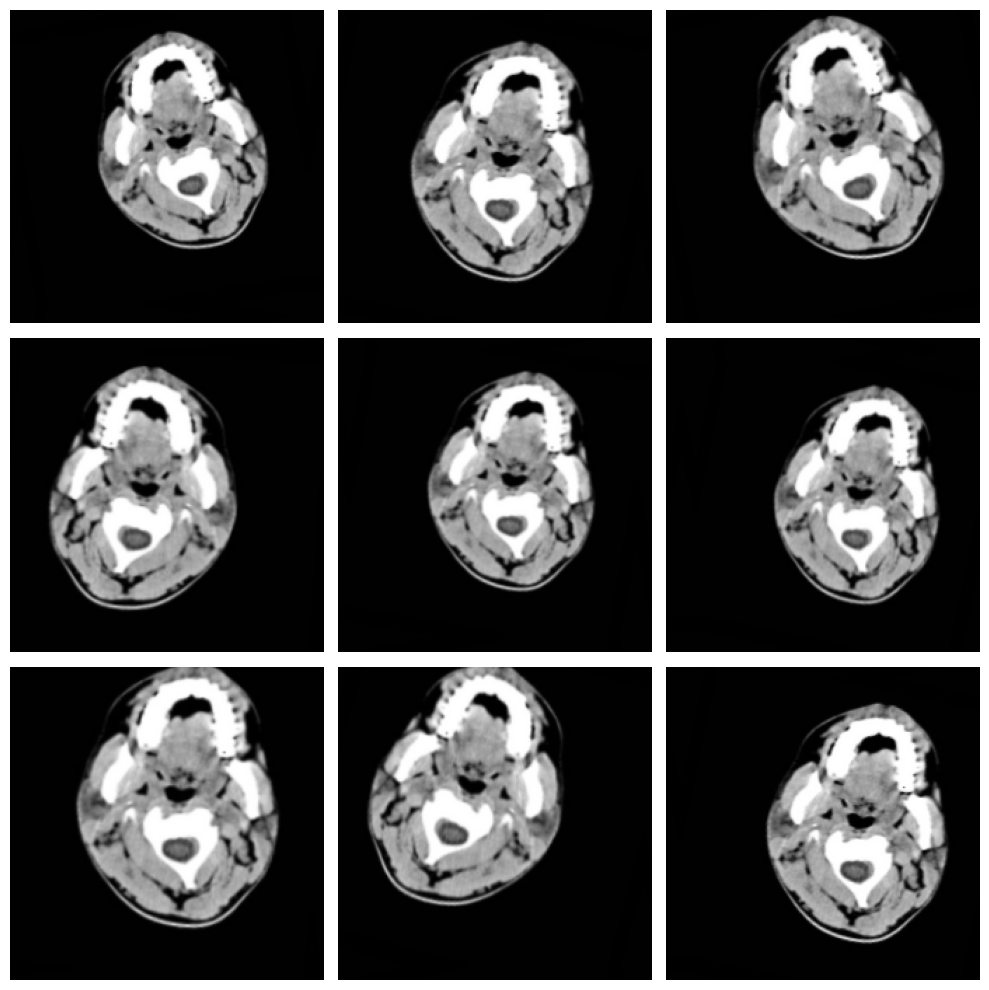

In [9]:
# Verify Augmentation
plt.figure(figsize=(10, 10))

for images, _ in train_ds.take(1):
    first_image = images[0]

    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)

        augmented_image = data_augmentation(
            tf.expand_dims(first_image, 0),
            training=True
        )

        plt.imshow(
            (augmented_image[0] + [103.939, 116.779, 123.68]) / 255.0
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

## Dataset Performance Optimization

To improve the efficiency of the training pipeline, TensorFlow's data pipeline optimization techniques are applied.

- **Cache** stores the dataset after the first iteration, reducing disk access in subsequent epochs.
- **Prefetch** overlaps data preprocessing and model execution, allowing the CPU to prepare future batches while the GPU processes the current batch.

These optimizations improve training speed without affecting model performance.

In [10]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Model Development
***

A transfer learning approach is adopted using the pre-trained **ResNet50** architecture. Instead of training a convolutional neural network from scratch, the model leverages features learned from the large-scale ImageNet dataset.

Initially, the convolutional base is used as a fixed feature extractor by freezing its weights. A custom classification head is then added to adapt the network to the binary stroke classification task.

In [11]:
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)


# Verify
print(base_model.input_shape)
print(base_model.output_shape)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
(None, 224, 224, 3)
(None, 7, 7, 2048)


## Freezing the Pre-trained Model

The convolutional layers of the pre-trained ResNet50 model are frozen during the initial training phase. This allows the network to act as a fixed feature extractor while only the newly added classification layers are trained.

Freezing the base model reduces training time, minimizes the risk of overfitting, and preserves the valuable features learned from the ImageNet dataset. Fine-tuning can be applied later by unfreezing selected layers.

In [12]:
base_model.trainable = False

# Verify
print("Base Model Trainable:", base_model.trainable)

Base Model Trainable: False


## Building the Classification Head

The original classification layer of ResNet50 is removed and replaced with a custom classification head designed for binary stroke detection.

A **Global Average Pooling** layer is used to reduce the spatial feature maps into a compact feature vector while preserving the most important information. This is followed by a fully connected layer with ReLU activation to learn task-specific patterns. A **Dropout** layer is added to reduce overfitting, and the final output layer consists of a single neuron with a **Sigmoid** activation function to predict the probability of the image belonging to the stroke class.

In [13]:
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    Input
)

from tensorflow.keras.models import Model


inputs = Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
base_model.trainable = False
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
outputs = Dense(1, activation="sigmoid")(x)

# Building The Model
model = Model(inputs, outputs)

# Verify
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## Model Compilation

The model is compiled using the **Adam** optimizer, which provides efficient gradient-based optimization and is widely used in deep learning applications.

Since the task is binary classification (Normal vs. Stroke), the **Binary Crossentropy** loss function is used together with a **Sigmoid** output layer.

In addition to accuracy, several evaluation metrics are monitored, including **Precision**, **Recall**, and **AUC**, to provide a more comprehensive assessment of the model's performance on this medical imaging task.

In [14]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),

    loss="binary_crossentropy",

    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

## Training Callbacks

Several callbacks are used during training to improve the learning process and prevent overfitting.

- **EarlyStopping** monitors the validation loss and stops training when no improvement is observed.
- **ModelCheckpoint** saves the best-performing model based on the validation loss.
- **ReduceLROnPlateau** automatically reduces the learning rate when the validation loss stops improving, allowing the optimizer to converge more effectively.

In [15]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)


early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)


checkpoint = ModelCheckpoint(
    "best_resnet50_model.keras",
    monitor="val_loss",
    save_best_only=True
)


reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-6
)


callbacks = [
    early_stopping,
    checkpoint,
    reduce_lr
]

In [16]:
# Start Training
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/20
 1/58 ━━━━━━━━━━━━━━━━━━━━ 15:09 16s/step - accuracy: 0.4375 - auc: 0.4246 - loss: 1.1908 - precision: 0.5000 - recall: 0.1111

I0000 00:00:1783533189.570530     175 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


58/58 ━━━━━━━━━━━━━━━━━━━━ 37s 365ms/step - accuracy: 0.5817 - auc: 0.5887 - loss: 0.7540 - precision: 0.4885 - recall: 0.4220 - val_accuracy: 0.6809 - val_auc: 0.7227 - val_loss: 0.5973 - val_precision: 0.5172 - val_recall: 0.5769 - learning_rate: 1.0000e-04
Epoch 2/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 107ms/step - accuracy: 0.6348 - auc: 0.6761 - loss: 0.6443 - precision: 0.5654 - recall: 0.4749 - val_accuracy: 0.7404 - val_auc: 0.7829 - val_loss: 0.5694 - val_precision: 0.5934 - val_recall: 0.6923 - learning_rate: 1.0000e-04
Epoch 3/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 107ms/step - accuracy: 0.6983 - auc: 0.7566 - loss: 0.5720 - precision: 0.6511 - recall: 0.5701 - val_accuracy: 0.7404 - val_auc: 0.8117 - val_loss: 0.5340 - val_precision: 0.6076 - val_recall: 0.6154 - learning_rate: 1.0000e-04
Epoch 4/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 108ms/step - accuracy: 0.7292 - auc: 0.7978 - loss: 0.5338 - precision: 0.6962 - recall: 0.6032 - val_accuracy: 0.7787 - val_auc: 0.8324 - val_loss: 0.4978 - v

# Model Evaluation

The trained model is evaluated on the unseen test dataset to assess its generalization performance. Multiple evaluation metrics are reported, including loss, accuracy, precision, recall, and AUC, providing a comprehensive assessment of the model's performance on stroke detection.

In [17]:
results = model.evaluate(test_ds, return_dict=True)

for metric, value in results.items():
    print(f"{metric}: {value:.4f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 429ms/step - accuracy: 0.7757 - auc: 0.8667 - loss: 0.4363 - precision: 0.6026 - recall: 0.7231       
accuracy: 0.7757
auc: 0.8667
loss: 0.4363
precision: 0.6026
recall: 0.7231


## Training History

The training and validation curves are visualized to monitor the learning process and detect potential overfitting or underfitting during training.

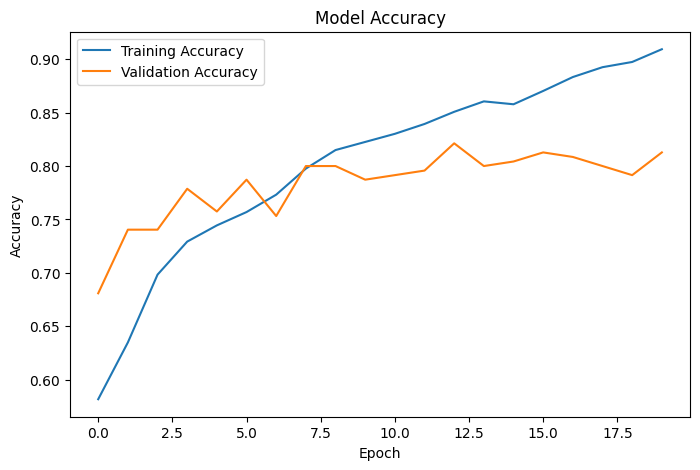

In [18]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

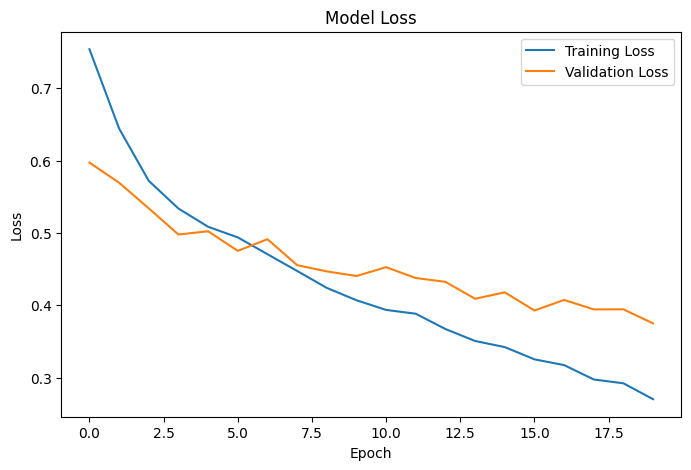

In [19]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [20]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)


y_prob = model.predict(test_ds)

y_pred = (y_prob >= 0.5).astype(int)

y_true = np.concatenate(
    [labels for _, labels in test_ds],
    axis=0
).astype(int)

cm = confusion_matrix(y_true, y_pred)

14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 393ms/step


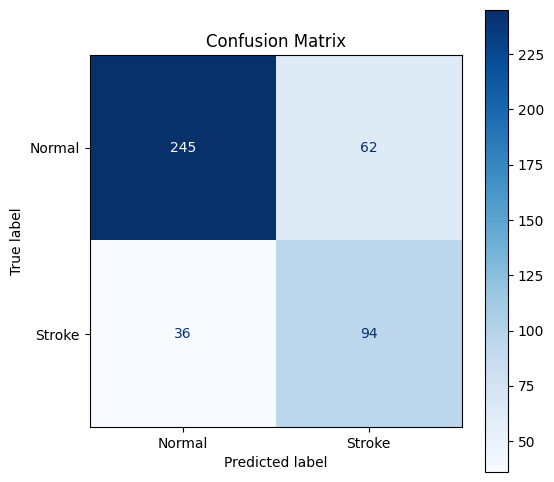

In [21]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Stroke"]
)

fig, ax = plt.subplots(figsize=(6,6))
disp.plot(cmap="Blues", ax=ax)

plt.title("Confusion Matrix")
plt.show()

In [22]:
print(classification_report(
    y_true,
    y_pred,
    target_names=["Normal","Stroke"]
))

              precision    recall  f1-score   support

      Normal       0.87      0.80      0.83       307
      Stroke       0.60      0.72      0.66       130

    accuracy                           0.78       437
   macro avg       0.74      0.76      0.75       437
weighted avg       0.79      0.78      0.78       437



In [23]:
# Save The Baseline Model
model.save("resnet50_baseline.keras")

# Fine-Tuning the Pre-trained ResNet50
***
After training the custom classification head, the model achieved promising performance using the frozen convolutional base. However, the extracted features were originally learned from the ImageNet dataset, which contains natural images rather than medical CT scans.

To further adapt the model to the stroke CT classification task, a fine-tuning strategy is applied. Instead of training the entire network from scratch, only the last convolutional layers of the pre-trained ResNet50 model are unfrozen while keeping the earlier layers frozen.

A very small learning rate is used during fine-tuning to preserve the previously learned features while allowing the model to learn domain-specific representations from CT images. This approach often improves the model's generalization performance without causing severe overfitting.

In [24]:
base_model.trainable = True

# Verify
print(base_model.trainable)

True


## Unfreezing the Last Layers

Rather than training the entire ResNet50 network, only the last convolutional layers are unfrozen for fine-tuning.

The earlier layers capture general visual features such as edges, textures, and simple shapes, which are useful across many image domains. In contrast, the deeper layers learn task-specific representations. Fine-tuning only the last layers allows the model to better adapt to CT scan images while reducing the risk of overfitting.

In [26]:
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Verify
trainable_layers = sum(layer.trainable for layer in base_model.layers)

print(f"Trainable Layers: {trainable_layers}")
print(f"Total Layers: {len(base_model.layers)}")

Trainable Layers: 30
Total Layers: 175


## Recompiling the Model

After modifying the trainable layers, the model must be recompiled before continuing the training process.

A smaller learning rate is adopted during fine-tuning to make subtle updates to the pre-trained weights. This helps preserve the useful features learned from ImageNet while allowing the model to adapt to the CT scan dataset.

The same loss function and evaluation metrics are retained to ensure a fair comparison with the baseline model.

In [28]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

## Fine-Tuning the Model

After unfreezing the last layers of the pre-trained ResNet50 model, the training process is continued using a significantly smaller learning rate.

Unlike the initial training phase, where only the custom classification head was trained, fine-tuning allows the deeper convolutional layers to adapt to the characteristics of brain CT images. This helps the model learn more domain-specific features while preserving the valuable knowledge acquired from the ImageNet dataset.

The same callbacks are used to prevent overfitting, reduce the learning rate when necessary, and automatically save the best-performing model.

The fine-tuning process resulted in a significant improvement across all evaluation metrics compared to the baseline model. The model achieved higher accuracy, precision, recall, and AUC, demonstrating its improved ability to distinguish between normal and stroke CT images.

During training, the training accuracy approached 100%, while the validation performance reached a stable plateau. This indicates that the model has already learned the available patterns within the dataset effectively. Continuing the fine-tuning process beyond this point is unlikely to provide meaningful performance gains and may increase the risk of overfitting.

Therefore, the fine-tuned model obtained at the best validation epoch is selected as the final model for subsequent evaluation and deployment.

In [31]:
fine_tune_checkpoint = ModelCheckpoint(
    "best_resnet50_finetuned.keras",
    monitor="val_loss",
    save_best_only=True
)

fine_tune_callbacks = [
    early_stopping,
    fine_tune_checkpoint,
    reduce_lr
]

In [32]:
# Start Training
fine_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=fine_tune_callbacks
)

Epoch 1/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 45s 432ms/step - accuracy: 0.8161 - auc: 0.8910 - loss: 0.4092 - precision: 0.7776 - recall: 0.7725 - val_accuracy: 0.8383 - val_auc: 0.9213 - val_loss: 0.3466 - val_precision: 0.9167 - val_recall: 0.5641 - learning_rate: 1.0000e-05
Epoch 2/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 164ms/step - accuracy: 0.9273 - auc: 0.9813 - loss: 0.2274 - precision: 0.9180 - recall: 0.9034 - val_accuracy: 0.8681 - val_auc: 0.9357 - val_loss: 0.3119 - val_precision: 0.8983 - val_recall: 0.6795 - learning_rate: 1.0000e-05
Epoch 3/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 166ms/step - accuracy: 0.9750 - auc: 0.9973 - loss: 0.1361 - precision: 0.9696 - recall: 0.9696 - val_accuracy: 0.8851 - val_auc: 0.9489 - val_loss: 0.2749 - val_precision: 0.9048 - val_recall: 0.7308 - learning_rate: 1.0000e-05
Epoch 4/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 166ms/step - accuracy: 0.9935 - auc: 0.9998 - loss: 0.0788 - precision: 0.9908 - recall: 0.9934 - val_accuracy: 0.8894 - val_auc: 0.9558 - val_lo

In [33]:
# Evaluation
results = model.evaluate(test_ds, return_dict=True)

for metric, value in results.items():
    print(f"{metric}: {value:.4f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 258ms/step - accuracy: 0.8696 - auc: 0.9417 - loss: 0.3493 - precision: 0.7325 - recall: 0.8846  
accuracy: 0.8696
auc: 0.9417
loss: 0.3493
precision: 0.7325
recall: 0.8846


In [34]:
# Predict probabilities
y_prob = model.predict(test_ds)

# Convert probabilities to class labels
y_pred = (y_prob >= 0.5).astype(int)

# True labels
y_true = np.concatenate(
    [labels for _, labels in test_ds],
    axis=0
).astype(int)

14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 382ms/step


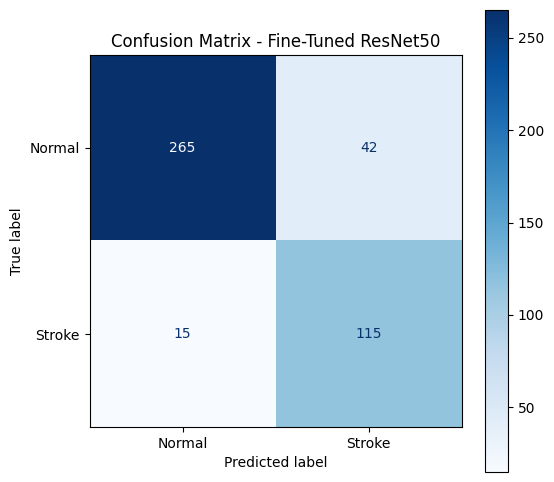

In [35]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Stroke"]
)

fig, ax = plt.subplots(figsize=(6,6))
disp.plot(cmap="Blues", ax=ax)

plt.title("Confusion Matrix - Fine-Tuned ResNet50")
plt.show()

In [36]:
print(classification_report(
    y_true,
    y_pred,
    target_names=["Normal", "Stroke"]
))

              precision    recall  f1-score   support

      Normal       0.95      0.86      0.90       307
      Stroke       0.73      0.88      0.80       130

    accuracy                           0.87       437
   macro avg       0.84      0.87      0.85       437
weighted avg       0.88      0.87      0.87       437



## Model Performance Analysis

The fine-tuned ResNet50 model demonstrated a clear improvement over the baseline model across all evaluation metrics. The confusion matrix shows that the model correctly classified 115 out of 130 stroke cases while misclassifying only 15 stroke cases as normal.

Compared to the baseline model, the number of false negatives decreased from 27 to 15, which represents a substantial improvement. In medical diagnosis, reducing false negatives is particularly important because undetected stroke cases may delay treatment and increase patient risk.

Additionally, the model achieved an overall test accuracy of 86.96%, an AUC score of 94.17%, and a recall of 88% for the stroke class, indicating a strong capability to identify stroke cases while maintaining good performance on normal cases.

These results demonstrate that fine-tuning the last layers of the pre-trained ResNet50 significantly enhanced the model's ability to learn domain-specific features from brain CT images.

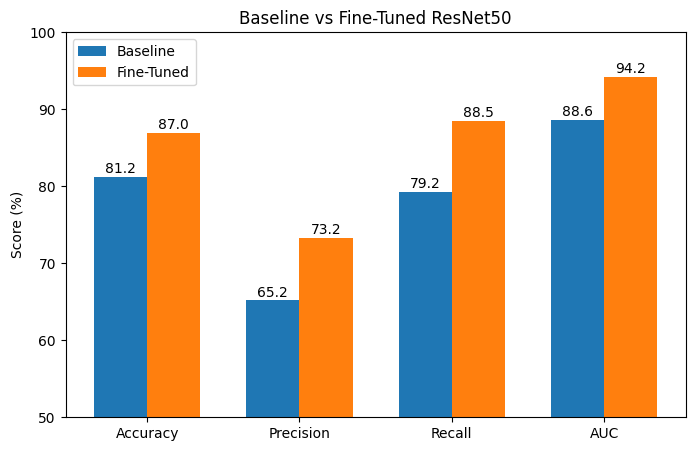

In [44]:
metrics = ["Accuracy", "Precision", "Recall", "AUC"]

baseline = [81.24, 65.19, 79.23, 88.62]
finetuned = [86.96, 73.25, 88.46, 94.17]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, baseline, width, label="Baseline")
plt.bar(x + width/2, finetuned, width, label="Fine-Tuned")

plt.xticks(x, metrics)
plt.ylabel("Score (%)")
plt.title("Baseline vs Fine-Tuned ResNet50")
plt.ylim(50,100)
plt.legend()

for i, v in enumerate(baseline):
    plt.text(i-width/2, v+0.5, f"{v:.1f}", ha='center')

for i, v in enumerate(finetuned):
    plt.text(i+width/2, v+0.5, f"{v:.1f}", ha='center')

plt.show()

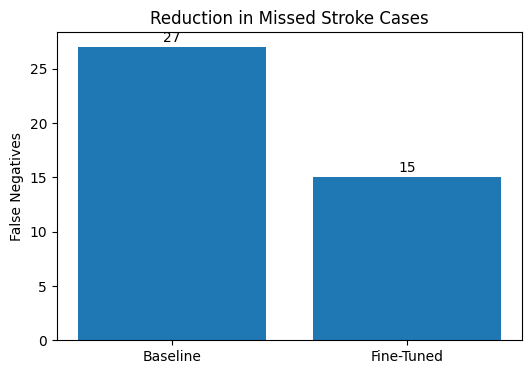

In [38]:
labels = ["Baseline", "Fine-Tuned"]
false_negatives = [27, 15]

plt.figure(figsize=(6,4))
bars = plt.bar(labels, false_negatives)

plt.ylabel("False Negatives")
plt.title("Reduction in Missed Stroke Cases")

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2,
             y+0.5,
             int(y),
             ha='center')

plt.show()

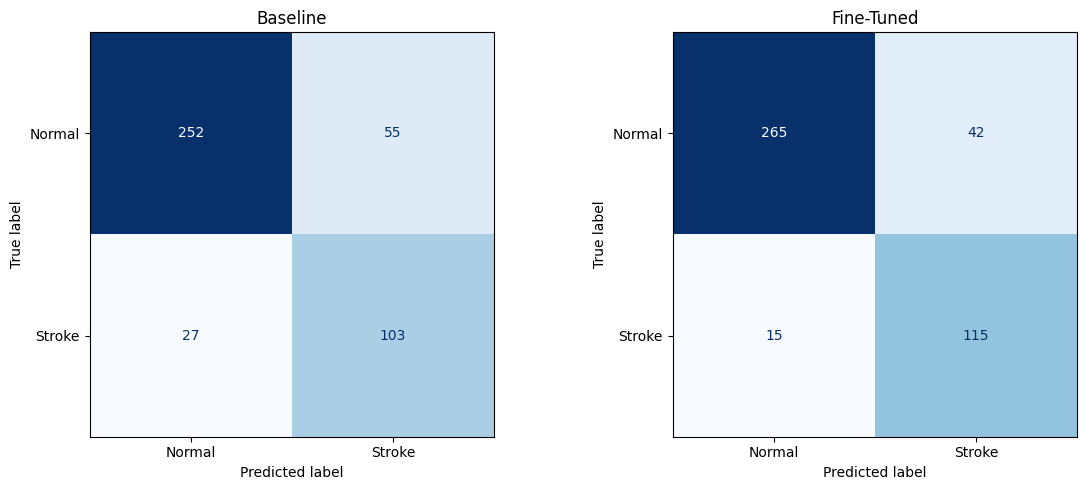

In [43]:
baseline_cm = np.array([
    [252, 55],
    [27, 103]
])

fine_cm = np.array([
    [265, 42],
    [15, 115]
])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(
    confusion_matrix=baseline_cm,
    display_labels=["Normal", "Stroke"]
).plot(ax=axes[0], cmap="Blues", colorbar=False)

axes[0].set_title("Baseline")

ConfusionMatrixDisplay(
    confusion_matrix=fine_cm,
    display_labels=["Normal", "Stroke"]
).plot(ax=axes[1], cmap="Blues", colorbar=False)

axes[1].set_title("Fine-Tuned")

plt.tight_layout()
plt.show()

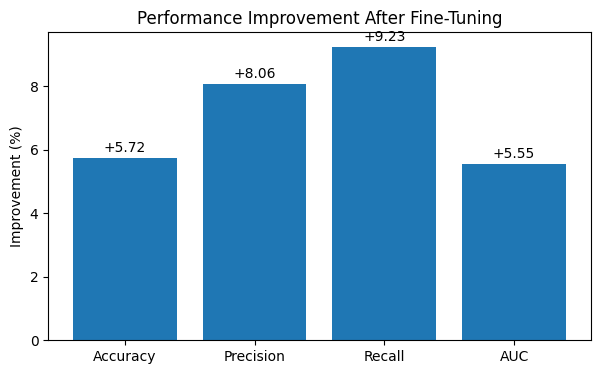

In [41]:
metrics = ["Accuracy","Precision","Recall","AUC"]

improvement = [
    86.96-81.24,
    73.25-65.19,
    88.46-79.23,
    94.17-88.62
]

plt.figure(figsize=(7,4))

bars = plt.bar(metrics, improvement)

plt.ylabel("Improvement (%)")
plt.title("Performance Improvement After Fine-Tuning")

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2,
             h+0.2,
             f"+{h:.2f}",
             ha="center")

plt.show()

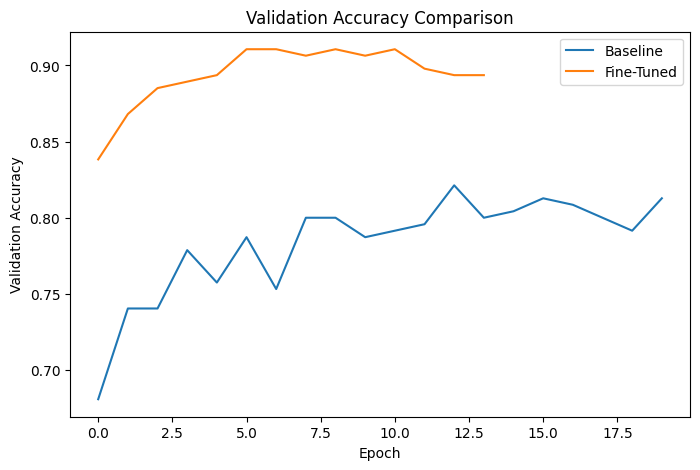

In [42]:
plt.figure(figsize=(8,5))

plt.plot(history.history["val_accuracy"], label="Baseline")
plt.plot(fine_history.history["val_accuracy"], label="Fine-Tuned")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()

plt.show()